In [1]:
import os
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import osmnx as ox
import numpy as np
from functools import lru_cache
from collections import defaultdict
from shapely.geometry import LineString
from shapely import wkt


/opt/anaconda3/lib/python3.13/site-packages/requests/__init__.py:113: RequestsDependencyWarning: urllib3 (2.5.0) or chardet (7.4.3)/charset_normalizer (3.4.4) doesn't match a supported version!
  warnings.warn(


## Links

In [2]:
transcad_links = gpd.read_file(r'/Users/jeannettearjona/Library/CloudStorage/OneDrive-InstitutoTecnologicoydeEstudiosSuperioresdeMonterrey/Modelación Urbana - Red Vial Guadalajara/Importacion TransCAD/Red Vial 2023 Python Cleaned/links_cleaned.shp')
osm_links = gpd.read_file(r'/Users/jeannettearjona/Library/CloudStorage/OneDrive-InstitutoTecnologicoydeEstudiosSuperioresdeMonterrey/Modelación Urbana - Red Vial Guadalajara/VisumLinks With TransCAD Atts/links con attributos x nombre/links_atts_longitudinal.shp')

# __TransCAD__

### __Las columnas que nos interesan son:__
- Limite_vel: límite de velocidad establecido de la vialidad
- CAPACIDAD: Capacidad en vehículos por hora de la vialidad
- Velocidad_: Promedio de velocidad de circulación de la vialidad calculado a partir de datos de uber

In [3]:
#Convertir a entero los valores de la columna 'Limite_vel' en el GeoDataFrame red_con_velocidades
transcad_links['Limite_vel'] = transcad_links['Limite_vel'].astype(int)
#Contar las filas para cada valor único de la columna 'Limite_vel' en el GeoDataFrame red_con_velocidades
transcad_links.groupby('Limite_vel').size()

Limite_vel
0        325
10        16
30    131153
40      4520
50      1059
60       569
80      1586
dtype: int64

Las que tienen velocidad 0 km/h son aquellos links por donde no se permite el paso de vehículos, como por ejemplo, calles peatonales. En transCAD era necesario agregarle una velocidad vehicular a estas calles por lo que al agregarles un límite de velocidad bajo el programa no les tomaba en cuenta para la asignación de tráfico.

### __Visualizar la red TransCAD con colores según los límites de velocidad__

<Axes: >

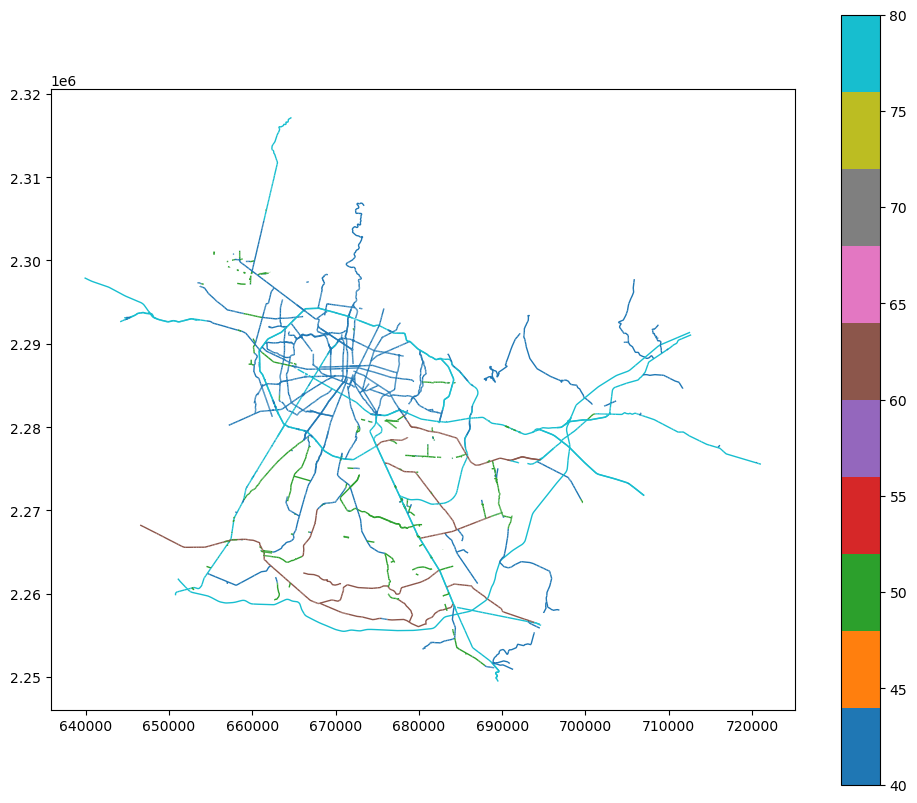

In [4]:
# Mapear tramos con velocidades mayores a 30 km/h
transcad_links[transcad_links["Limite_vel"] > 30].plot(
    column="Limite_vel",
    cmap="tab10",
    legend=True,
    figsize=(12, 10),
    linewidth=1
)

In [5]:
# stay only with those above 40 km/h
transcad_main=transcad_links[transcad_links["Limite_vel"] >= 40].copy()

In [6]:
BUFFER = 25
regex_conectores = (r"DESNIVEL|DEPRIMIDO|SALIDA|ENTRADA|RETORNO")
regex_laterales = (r"LATERAL")
connector_attrs = []


# 1) Group by name
for road_name, group in transcad_main.groupby("NOMBRE"):
    if pd.isna(road_name):
        continue
    
    # 2) Buffer the geometry of the group
    corridor_geom = group.geometry.union_all()
    corridor_buffer = corridor_geom.buffer(BUFFER)

    # 3) Find links within the buffer
    inside_buffer = transcad_links[
        transcad_links.geometry.intersects(corridor_buffer)
    ].copy()

    # 4) Filter out links that match the regex pattern
    transcad_connectors = inside_buffer[
        inside_buffer["NOMBRE"].str.contains(regex_conectores, na=False, case=False, regex=True)
    ].copy()
    
    transcad_laterales = inside_buffer[
        inside_buffer["NOMBRE"].str.contains(regex_laterales, na=False, case=False, regex=True)
    ].copy()

    #if (len(transcad_connectors) == 0) and (len(transcad_laterales) == 0):
    #    continue

    # 5) Store the attributes of the connectors
    connector_attrs.append({
        "road_name": road_name,
        "conn_cap": transcad_connectors["CAPACIDAD"].median() if (len(transcad_connectors) > 0) else 0,
        "conn_velprom": transcad_connectors["Velocidad_"].median() if (len(transcad_connectors) > 0) else 0,
        "conn_limvel": transcad_connectors["Limite_vel"].median() if (len(transcad_connectors) > 0) else 0,
        "lat_cap": transcad_laterales['CAPACIDAD'].median() if (len(transcad_laterales) > 0) else 0,
        "lat_velprom": transcad_laterales['Velocidad_'].median() if (len(transcad_laterales) > 0) else 0,
        "lat_limvel": transcad_laterales['Limite_vel'].median() if (len(transcad_laterales) > 0) else 0,
        "n_conn": len(transcad_connectors),
        "n_lat": len(transcad_laterales),
        "geometry": corridor_buffer
    })

connector_buffers = gpd.GeoDataFrame(
    connector_attrs,
    geometry="geometry",
    crs=transcad_links.crs
)


In [7]:
connector_buffers

,road_name,conn_cap,conn_velprom,conn_limvel,lat_cap,lat_velprom,lat_limvel,n_conn,n_lat,geometry
0,13 DE AGOSTO,0.0,0.000000,0.0,0.0,0.000000,0.0,0,0,"POLYGON ((681836.876 2278415.944, 681836.881 2..."
1,16 DE SEPTIEMBRE,0.0,0.000000,0.0,0.0,0.000000,0.0,0,0,"POLYGON ((671721.55 2285113.671, 671720.514 22..."
2,"18 DE MARZO, AV.",0.0,0.000000,0.0,0.0,0.000000,0.0,0,0,"POLYGON ((664837.477 2281745.886, 664835.462 2..."
3,1o. DE MAYO,0.0,0.000000,0.0,0.0,0.000000,0.0,0,0,"POLYGON ((671864.254 2272812.018, 671818.65 22..."
4,2 DE ABRIL,0.0,0.000000,0.0,0.0,0.000000,0.0,0,0,"POLYGON ((672107.795 2291723.317, 672107.786 2..."
...,...,...,...,...,...,...,...,...,...,...
340,"ZAPATA, EMILIANO",0.0,0.000000,0.0,3000.0,16.000020,30.0,0,3,"MULTIPOLYGON (((675903.254 2275719.434, 675905..."
341,"ZAPOTLANEJO, A, AUT.",4000.0,33.999945,80.0,4000.0,24.000000,30.0,2,10,"POLYGON ((680138.388 2281043.959, 680201.49 22..."
342,"ZAPOTLANEJO, A, CARR.",4000.0,33.999987,80.0,4000.0,23.999967,30.0,1,13,"MULTIPOLYGON (((700558.694 2280878.306, 700654..."
343,"ZAPOTLANEJO, LIBRE A, CARR.",0.0,0.000000,0.0,0.0,0.000000,0.0,0,0,"POLYGON ((689598.748 2276192.616, 689525.734 2..."


In [8]:
connector_buffers.to_file(r'/Users/jeannettearjona/Library/CloudStorage/OneDrive-InstitutoTecnologicoydeEstudiosSuperioresdeMonterrey/Modelación Urbana - Red Vial Guadalajara/VisumLinks With TransCAD Atts/TransCAD/medianas conectores avenidas/conectores_avenidas.shp')

/var/folders/8s/00_wwq9j23b09mnd7gp105m00000gp/T/ipykernel_2372/2131638198.py:1: UserWarning: Column names longer than 10 characters will be truncated when saved to ESRI Shapefile.
  connector_buffers.to_file(r'/Users/jeannettearjona/Library/CloudStorage/OneDrive-InstitutoTecnologicoydeEstudiosSuperioresdeMonterrey/Modelación Urbana - Red Vial Guadalajara/VisumLinks With TransCAD Atts/TransCAD/medianas conectores avenidas/conectores_avenidas.shp')
/opt/anaconda3/lib/python3.13/site-packages/pyogrio/raw.py:733: RuntimeWarning: Normalized/laundered field name: 'conn_velprom' to 'conn_velpr'
  ogr_write(
/opt/anaconda3/lib/python3.13/site-packages/pyogrio/raw.py:733: RuntimeWarning: Normalized/laundered field name: 'conn_limvel' to 'conn_limve'
  ogr_write(
/opt/anaconda3/lib/python3.13/site-packages/pyogrio/raw.py:733: RuntimeWarning: Normalized/laundered field name: 'lat_velprom' to 'lat_velpro'
  ogr_write(


# __OSM__

In [9]:
# 1) Change CRS to meters
osmnx_links = osm_links.to_crs(transcad_links.crs).copy()

### __Pass TransCAD medians__ for capacity & speed __to OSM cuchillas__ that intersect with main avenues

In [12]:
# 2) Identify OSM connectors based on highway types
regex_osm_connectors = (r"primary_link|trunk_link|secondary_link|tertiary_link")
osm_connectors = osmnx_links[
    osmnx_links["highway"].str.contains(regex_osm_connectors, na=False, case=False, regex=True)
].copy()

# 3) Spatial join to find OSM connectors within the buffers
osm_connectors_within_buffers = gpd.sjoin(
    osm_connectors,
    connector_buffers[['road_name','conn_cap', 'conn_velprom', 'conn_limvel','geometry']],
    how="inner",
    predicate="intersects"
)

In [13]:
osm_connectors_within_buffers.to_file(r'/Users/jeannettearjona/Library/CloudStorage/OneDrive-InstitutoTecnologicoydeEstudiosSuperioresdeMonterrey/Modelación Urbana - Red Vial Guadalajara/VisumLinks With TransCAD Atts/OSM/atts cuchillas/osm_atts_cuchillas.shp')

/var/folders/8s/00_wwq9j23b09mnd7gp105m00000gp/T/ipykernel_2372/4246747404.py:1: UserWarning: Column names longer than 10 characters will be truncated when saved to ESRI Shapefile.
  osm_connectors_within_buffers.to_file(r'/Users/jeannettearjona/Library/CloudStorage/OneDrive-InstitutoTecnologicoydeEstudiosSuperioresdeMonterrey/Modelación Urbana - Red Vial Guadalajara/VisumLinks With TransCAD Atts/OSM/atts cuchillas/osm_atts_cuchillas.shp')
/opt/anaconda3/lib/python3.13/site-packages/pyogrio/raw.py:733: RuntimeWarning: Normalized/laundered field name: 'index_right' to 'index_righ'
  ogr_write(
/opt/anaconda3/lib/python3.13/site-packages/pyogrio/raw.py:733: RuntimeWarning: Normalized/laundered field name: 'conn_velprom' to 'conn_velpr'
  ogr_write(
/opt/anaconda3/lib/python3.13/site-packages/pyogrio/raw.py:733: RuntimeWarning: Normalized/laundered field name: 'conn_limvel' to 'conn_limve'
  ogr_write(


### __Pass TransCAD medians__ for capacity & speed __to OSM Laterals__ that intersect with main avenues

In [14]:
# 2) Identify OSM connectors based on highway types
regex_osm_laterals = (r"Lateral")

osm_laterals = osmnx_links[
    osmnx_links["name"].str.contains(regex_osm_laterals, na=False, case=False, regex=True)
].copy()

# 3) Spatial join to find OSM connectors within the buffers
osm_laterals_within_buffers = gpd.sjoin(
    osm_laterals,
    connector_buffers[['road_name','lat_cap', 'lat_velprom', 'lat_limvel','geometry']],
    how="inner",
    predicate="intersects"
)

In [17]:
osm_laterals_within_buffers.to_file(r'/Users/jeannettearjona/Library/CloudStorage/OneDrive-InstitutoTecnologicoydeEstudiosSuperioresdeMonterrey/Modelación Urbana - Red Vial Guadalajara/VisumLinks With TransCAD Atts/OSM/atts laterales/osm_atts_laterales.shp')

/var/folders/8s/00_wwq9j23b09mnd7gp105m00000gp/T/ipykernel_2372/825681562.py:1: UserWarning: Column names longer than 10 characters will be truncated when saved to ESRI Shapefile.
  osm_laterals_within_buffers.to_file(r'/Users/jeannettearjona/Library/CloudStorage/OneDrive-InstitutoTecnologicoydeEstudiosSuperioresdeMonterrey/Modelación Urbana - Red Vial Guadalajara/VisumLinks With TransCAD Atts/OSM/atts laterales/osm_atts_laterales.shp')
/opt/anaconda3/lib/python3.13/site-packages/pyogrio/raw.py:733: RuntimeWarning: Normalized/laundered field name: 'index_right' to 'index_righ'
  ogr_write(
/opt/anaconda3/lib/python3.13/site-packages/pyogrio/raw.py:733: RuntimeWarning: Normalized/laundered field name: 'lat_velprom' to 'lat_velpro'
  ogr_write(
